# Conceitos básicos do Pytorch

Aprendendo o básico das funções a partir da aula 5 do curso de processamento de imagem do IMPA no YouTube

https://youtu.be/W_anAt95N2k

## Tensores

Estrutura de dados básica para manipular os dados na biblioteca.

In [ ]:
import torch

#2x2 tensor construido com um array regular
T = torch.tensor( [[1.5, 2], [3, 4]])

# Tem estrutura similar ao numpy
T_zeros = torch.zeros(100, 100)
T_ones = torch.ones(100, 100)
T_random = torch.randn(100, 100)

# dtype define o tipo de dado
T_int = torch.tensor( [[1, 2], [3, 4]], dtype=torch.int)
T_double = torch.randn( 3, 5, 7, dtype=torch.double)

print(T.dtype)
print(T.size())

### Operações com Tensores

In [ ]:
import torch
x = torch.randn(3,3, dtype=torch.float64)
y = torch.randn(3,3, dtype=torch.float64)

# Adição e subtração
z = x + y
z = torch.add(x, y)
w = x - y
w = torch.sub(x, y)

# Obs: Usar tensores de mesma dimensão nas operações

# Multiplicação e divisão elemento a elemento
u = x * y
u = torch.mul(x, y)
v = x / y
v = torch.div(x, y)

# Operações implicitas
y.add_(x)
x.mul_(y)

### Index de tensores

In [ ]:
import torch
x = torch.randn(6,6, dtype=torch.float64)
y = torch.randn(6,6, dtype=torch.float64)

# Indexing and Slicing
x_row = x[3,:]
x_cln = x[:,3]
x_e = x[0,0].item() # Esse método item obtém o escalar do tensor

# Redimencionar
z = y.view(36)
w = y.view(-1, 9) # 4x9 tensor
# O valor -1 no método view indica que o valor deve ser calculado dinâmicamente, ou seja, a quantidade de colunas para preencher toda a matriz

### Usando a GPU

In [ ]:
import torch
device = torch.device("cuda")
x = torch.randn(5, 5, device=device)
'''
Caso de mais de uma GPU:
device2 = torch.device("cuda:2")
x2 = torch.randn(5, 5, device=device2)
'''

y = torch.ones(5, 5)
y = y.to(device=device) #executar um tensor já iniciado em outro device (da CPU para GPU ou uma outra GPU)

# Operações devem ser feitas no mesmo device
z = x + y


## Autograd

Auxilia na criação de grafos de conexões


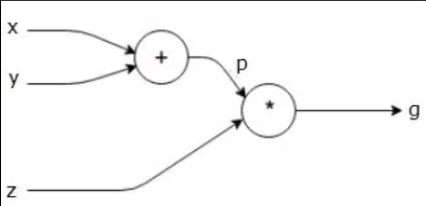

In [ ]:
import torch

x = torch.randn(3, requires_grad=True)
y = torch.randn(3, requires_grad=True)
z = torch.randn(3, requires_grad=False)

p = x + y
print(p)
g = p*z
print(g)
g = g.mean()
print(g)

g.backward() #dg/dx, dg/dy
print(x.grad)
print(y.grad)
print(z.grad)

# z.grad é None porque requer_grad=False (atua como constante fixa)
# p.grad é None porque é um nó intermediário (o gradiente "passa", mas não "mora" aqui)
# x.grad e y.grad existem porque são a base (folhas) do cálculo

# Mudando a computação do gradiente
x.requires_grad(False)
y.detach() # Tira o tensor do grafo mas ele ainda apresenta um ponteiro para o vetor
with torch.no_grad(): # Cria um ambente que nenhuma das variáveis tem gradiente
    ...

### Acumulação dos valores do gradiente

In [ ]:
import torch
W = torch.randn(4, requires_grad=True)

for epoch in range(3):
    out = (W*5).sum()
    out.backward()
    # Gradiente acumulado
    print(W.grad)
    # W.grad.zero_() # Serve para eliminar o gradiente acumulado

## Layers - torch.nn

Criação de camadas, funções de ativação, funções de perda, ect. Para criar um modelo de rede neural

In [ ]:
import torch
L = torch.nn.Linear(10, 25) # Criação de uma camada linear

x = torch.randn(3, 10)
y = L(x)
print(y.size())

model = torch.nn.Sequential(L,
                            torch.nn.ReLU(),
                            torch.nn.Linear(25,5))
y = model(x)
print(y.size())

## Construindo Redes Neurais

Criação de uma rede neural de duas camadas

In [22]:
import torch
import torch.nn as nn 

class TwoLayerNN(nn.Module):
    def __init__(self, dim_in, dim_hidden, dim_out):
        super(TwoLayerNN, self).__init__()

        # Definição das camadas e da função de ativação
        self.linear1 = nn.Linear(dim_in, dim_hidden)
        self.act = nn.ReLU()
        self.linear2 = nn.Linear(dim_hidden, dim_out)
    
    # Ligação da rede neural
    def forward(self, x):
        h = self.linear1(x)
        h = self.act(h)
        y = self.linear2(h)
        return y

# Exemplo
n_batch, dim_in, dim_hidden, dim_out = 3, 100, 50, 10
x = torch.randn(n_batch, dim_in)

model = TwoLayerNN(dim_in, dim_hidden, dim_out)
pred = model(x)

print(pred)


tensor([[-0.0740,  0.3701, -0.0662,  0.0963, -0.0112, -0.0168,  0.1488, -0.1426,
         -0.5566,  0.0950],
        [ 0.1983,  0.3912,  0.3049,  0.4335, -0.2145, -0.4077, -0.1018, -0.2364,
         -0.4757,  0.3458],
        [ 0.2308,  0.6294, -0.2461,  0.1108, -0.2033, -0.3471,  0.2185,  0.3158,
         -0.3304, -0.1601]], grad_fn=<AddmmBackward0>)


### Tratamento de dados

Carregando repoistório de imagens

In [23]:
import torch
import torchvision
from torchvision.datasets import MNIST # Dataset de reconhecimento de digitos
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import os

mnist_data = MNIST(os.getcwd(),
                   download=True,
                   transform=transforms.ToTensor())

# Forma de caminhar pelo banco e fazer amostras
data_loader = DataLoader(mnist_data,
                         batch_size=4,
                         shuffle=True)


### Funções de Perda

Verificação da acuracidade do modelo

In [24]:
import torch
import torch.nn.functional as F

# Pega um item do dataset
x, y = mnist_data[0]

# Define as dimensões
dim_in = x.view(-1).shape[0] 
dim_hidden, dim_out = 100, 10
model = TwoLayerNN(dim_in, dim_hidden, dim_out)

# Prepara a entrada: achata a imagem para (1, 784)
# O modelo espera (N, dim_in)
input_tensor = x.view(1, -1) 
pred = model(input_tensor)

# Cálculo da Loss: O target precisa ser Long
# y é um inteiro simples, transformamos em tensor Long de tamanho (1,)
target = torch.tensor([y], dtype=torch.long)
loss = F.cross_entropy(pred, target)

print(f"Loss calculada: {loss.item():.4f}")


Loss calculada: 2.2401


### Optimizer (Otimizador)

In [ ]:
import torch
import torch.optim as optim

# Ajuste da dimensão de entrada (C * H * W)
dim_in = 1 * 28 * 28 
dim_hidden, dim_out = 100, 10
model = TwoLayerNN(dim_in, dim_hidden, dim_out)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

for batch in data_loader:
    x, y = batch  # x: [4, 1, 28, 28], y: [4]
    
    # Flatten: Transforma [4, 1, 28, 28] em [4, 784]
    x_flat = x.view(x.size(0), -1)
    
    # Forward pass
    pred = model(x_flat)
    
    # Cálculo da Loss: 
    # O 'y' vindo do DataLoader já é um LongTensor! Não precisa de torch.tensor([y])
    loss = F.cross_entropy(pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Loss: {loss.item():.4f}")

### Loop de Validação

In [ ]:
train, val = random_split(mnist_data, [55000, 5000])
data_train = DataLoader(train)
data_val = DataLoader(val)

with torch.no_grad():
    for batch in data_val:
        x, y = batch
        loss = loss_function(model(x), y)
        print(loss)
        ...
        # Acuracia